In [1]:
!pip install transformers timm torch torchvision --quiet

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/datasets/pcb_defects/PCB_DATASET/rotation"

import os
print(os.listdir(DATASET_PATH))

Mounted at /content/drive
['Missing_hole_angles.txt', 'Mouse_bite_angles.txt', 'Open_circuit_angles.txt', 'Short_angles.txt', 'Spur_angles.txt', 'Spurious_copper_angles.txt', 'Missing_hole_rotation', 'Mouse_bite_rotation', 'Open_circuit_rotation', 'Short_rotation', 'Spur_rotation', 'Spurious_copper_rotation']


In [4]:
# Dataset Loader y transformaciones de imagen

import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoModelForImageClassification

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

class PCBDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.images = []
        self.labels = []

        self.classes = []

        # recorrer carpetas
        for folder in os.listdir(root_dir):

            folder_path = os.path.join(root_dir, folder)

            if os.path.isdir(folder_path):

                self.classes.append(folder)

                for img in os.listdir(folder_path):

                    if img.lower().endswith(".jpg"):

                        self.images.append(os.path.join(folder_path, img))
                        self.labels.append(folder)


        # convertir labels a números
        self.classes.sort()
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        self.labels = [self.class_to_idx[l] for l in self.labels]


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
# Cargar dataset
dataset = PCBDataset(DATASET_PATH, transform)

print("Total imágenes:", len(dataset))
print("Clases:", dataset.class_to_idx)

Total imágenes: 693
Clases: {'Missing_hole_rotation': 0, 'Mouse_bite_rotation': 1, 'Open_circuit_rotation': 2, 'Short_rotation': 3, 'Spur_rotation': 4, 'Spurious_copper_rotation': 5}


In [6]:
# Train / Test split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [7]:
# Cargar modelo

model = AutoModelForImageClassification.from_pretrained(
    "apple/mobilevit-small",
    num_labels=6,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

MobileViTForImageClassification LOAD REPORT from: apple/mobilevit-small
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 640]) vs model:torch.Size([6, 640])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


MobileViTForImageClassification(
  (mobilevit): MobileViTModel(
    (conv_stem): MobileViTConvLayer(
      (convolution): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (normalization): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLUActivation()
    )
    (encoder): MobileViTEncoder(
      (layer): ModuleList(
        (0): MobileViTMobileNetLayer(
          (layer): ModuleList(
            (0): MobileViTInvertedResidual(
              (expand_1x1): MobileViTConvLayer(
                (convolution): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): SiLUActivation()
              )
              (conv_3x3): MobileViTConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)

In [8]:
# Entrenamiento

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

criterion = torch.nn.CrossEntropyLoss()

epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).logits

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

Epoch 1 Loss: 1.7925301040921893
Epoch 2 Loss: 1.7894200325012206
Epoch 3 Loss: 1.7810082503727505
Epoch 4 Loss: 1.7767062868390764
Epoch 5 Loss: 1.7699356624058316


In [9]:
# Evaluacón

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).logits

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Accuracy:", correct/total)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Accuracy: 0.2014388489208633
Train samples: 554
Test samples: 139


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

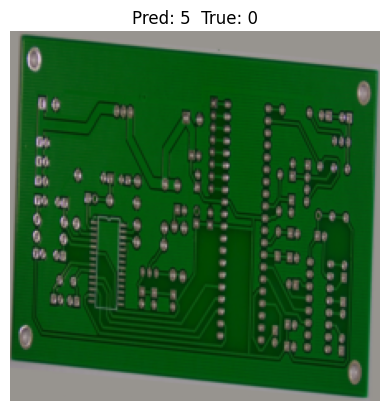

In [10]:
# Probar una imagen

import matplotlib.pyplot as plt

image, label = dataset[10]

model.eval()

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device)).logits
    pred = torch.argmax(pred,dim=1)

plt.imshow(image.permute(1,2,0))
plt.title(f"Pred: {pred.item()}  True: {label}")
plt.axis("off")